<a href="https://colab.research.google.com/github/joyanto7/skm-assignments/blob/main/Assignment_4_(Matplotlib_%26_Seaborn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Sensible global defaults so every plot looks consistent by skill
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi']     = 100

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# students = pd.read_csv('/content/drive/MyDrive/datasets/StudentsPerformance.csv')
gym      = pd.read_csv('/content/drive/MyDrive/datasets/gym_membership.csv')

Mounted at /content/drive


# **Matplotlib Assignment**

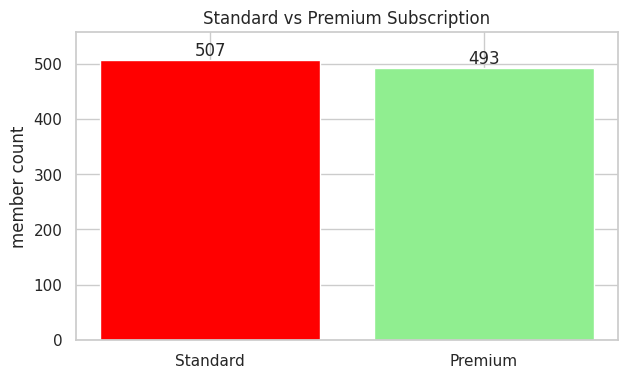

In [50]:
# no. 1 --> Bar chart of membership types — gym['abonoment_type'].value_counts()

abonoment_count = gym['abonoment_type'].value_counts()
abonoment_count

fig, ax = plt.subplots()

bars = ax.bar(abonoment_count.index, abonoment_count.values, color = ['red', 'lightgreen'])
ax.bar_label(bars, fmt = '%.0f', padding = 0.02)

ax.margins(y = 0.10)

ax.set(title = 'Standard vs Premium Subscription', ylabel = 'member count')
plt.show()

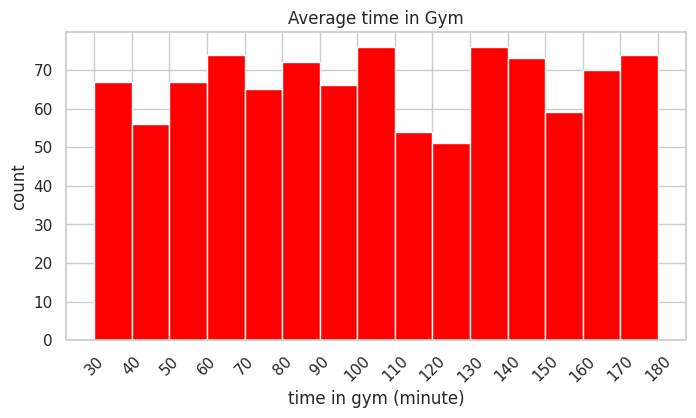

In [6]:
# no.2 --> Histogram of avg_time_in_gym

# gym['avg_time_in_gym'].min() --> 30
# gym['avg_time_in_gym'].max() --> 180

ticks_and_bins = np.arange(30, 181, 10)

fig, ax = plt.subplots(figsize = (8, 4))

ax.set_xticks(ticks_and_bins)

ax.hist(gym['avg_time_in_gym'], bins = ticks_and_bins, color = 'red', edgecolor = 'white')
ax.set(title = 'Average time in Gym', xlabel = 'time in gym (minute)', ylabel = 'count')

plt.xticks(rotation = 45)
plt.show()

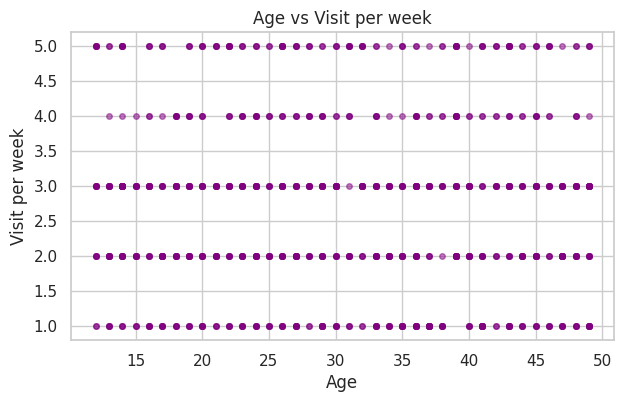

In [7]:
# no. 3 Scatter plot of Age vs visit_per_week

fig, ax = plt.subplots()

ax.scatter(gym['Age'], gym['visit_per_week'], alpha = 0.5, s = 16, color = 'purple')
ax.set(title = 'Age vs Visit per week', xlabel = 'Age', ylabel = 'Visit per week')
plt.show()

# **Seaborn Assignment**

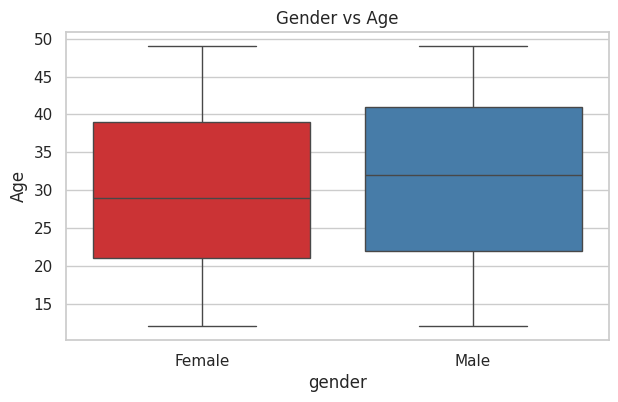

In [8]:
# no. 1 Box Plot --> Gender vs Age

fig, ax = plt.subplots(figsize = (7, 4))

sns.boxplot(data = gym, x = 'gender', y = 'Age', palette = 'Set1', hue = 'gender', ax = ax)
ax.set_title('Gender vs Age')
plt.show()


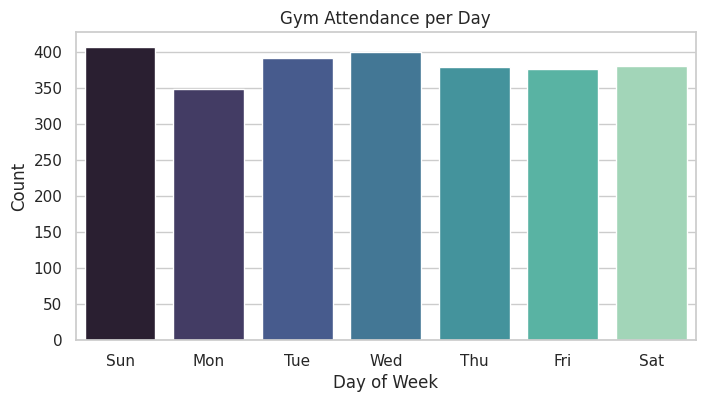

In [10]:
# no. 2 Count Plot days_per_week ( I took help of Claude AI, but I can explain)


gym['days_list'] = gym['days_per_week'].str.split(',').apply(lambda x: [d.strip() for d in x])

exploded = gym.explode('days_list')

fig, ax = plt.subplots(figsize = (8, 4))
sns.countplot(data=exploded, x='days_list',
              order=['Sun','Mon','Tue','Wed','Thu','Fri','Sat'],
              ax = ax,
              palette='mako')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.title('Gym Attendance per Day')
plt.show()

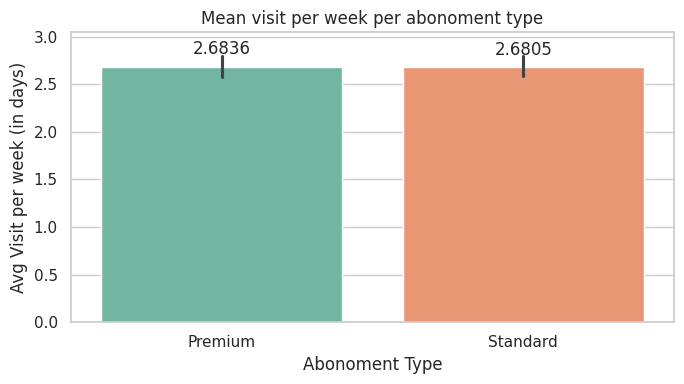

In [47]:
# no. 3 Bar plot —> mean visit_per_week per abonoment_type


fig, ax = plt.subplots()
sns.barplot(data = gym, x = 'abonoment_type', y = 'visit_per_week',
            palette = 'Set2', ax = ax)

ax.margins(y=0.09)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding = 6)

ax.set(title = 'Mean visit per week per abonoment type', xlabel = 'Abonoment Type', ylabel = 'Avg Visit per week (in days)')

plt.tight_layout()
plt.show()